# BME i9400 — Meeting 5
## Studio: PCA of a Gene Expression Matrix

**Fall 2026 · Wednesday, September 16**

Today you implement the method from Meeting 4 on the tumour expression matrix: centering, the
singular value decomposition, the scree plot, the projection, and a measurement of what the
compression costs.

**Agenda**

1. Loading and inspecting the matrix
2. Centering
3. The singular value decomposition
4. Choosing how many components to keep
5. Projecting and plotting
6. What does PC1 actually measure?
7. What the compression costs
8. Submitting your work

Section 1 is done for you — just read and run it. Sections 2 to 7 contain tasks marked `TODO` that
you are asked to complete. Each task ends with checks that must pass before you move on.

---
## 1 — Loading and inspecting the matrix

The data is a subset of The Cancer Genome Atlas: 801 tumour samples, each with expression levels for
the 400 genes that vary most across the collection, plus a label giving the cancer type.

> **RNA-seq** measures how strongly each gene is being expressed in a tissue sample. A higher number
> means more of that gene's RNA was present.

The five cancer types are BRCA (breast), COAD (colon), KIRC (kidney), LUAD (lung), and PRAD
(prostate).

**The labels are used only for colouring the plots.** Every calculation in sections 2 to 5 sees the
expression matrix alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12, "figure.dpi": 110})

URL = "https://raw.githubusercontent.com/dmochow/BME-i9400-2026/main/data/tcga_rnaseq_subset.csv"
df  = pd.read_csv(URL)

y = df["cancer_type"].values                    # labels, for plotting only
X = df.drop(columns="cancer_type").values       # the expression matrix
genes = df.drop(columns="cancer_type").columns  # gene names, for section 6

print(f"X has shape {X.shape}  ->  n = {X.shape[0]} samples, d = {X.shape[1]} genes")
print("cancer types:", ", ".join(f"{c} ({(y==c).sum()})" for c in sorted(set(y))))
print(f"\nexpression values range from {X.min():.2f} to {X.max():.2f}")
df.iloc[:4, :5] # first four rows, first five columns

X has shape (801, 400)  ->  n = 801 samples, d = 400 genes
cancer types: BRCA (300), COAD (78), KIRC (146), LUAD (141), PRAD (136)

expression values range from 0.00 to 20.78


,cancer_type,gene_9176,gene_9175,gene_15898,gene_15301
0,PRAD,18.525,17.174,1.334,13.618
1,LUAD,0.000,0.000,13.609,0.000
2,PRAD,16.054,14.818,1.074,12.760
3,PRAD,18.372,17.371,0.435,12.353


In [2]:
#sorted(set(y))
df

,cancer_type,gene_9176,gene_9175,gene_15898,gene_15301,gene_15589,gene_3540,gene_19661,gene_3541,gene_11250,...,gene_3542,gene_6784,gene_14114,gene_15795,gene_11345,gene_16156,gene_10876,gene_30,gene_19593,gene_6111
0,PRAD,18.525,17.174,1.334,13.618,0.000,4.997,1.095,5.788,18.016,...,1.010,10.730,0.000,7.957,9.287,0.0,4.305,0.000,7.043,5.268
1,LUAD,0.000,0.000,13.609,0.000,0.000,6.737,11.170,13.060,1.004,...,1.591,1.327,0.000,5.303,0.588,0.0,2.007,0.000,3.891,1.814
2,PRAD,16.054,14.818,1.074,12.760,0.000,7.010,0.000,5.155,7.800,...,2.110,0.000,0.000,0.000,2.439,0.0,2.707,0.000,0.453,9.682
3,PRAD,18.372,17.371,0.435,12.353,0.000,5.445,1.032,5.983,11.913,...,2.059,9.130,0.435,3.128,4.270,0.0,0.769,0.000,0.435,9.461
4,BRCA,0.000,1.580,1.096,0.000,14.976,8.078,12.783,8.350,1.096,...,4.346,2.968,0.000,8.657,1.580,0.0,1.711,0.000,0.890,0.361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,BRCA,1.612,1.956,0.000,0.000,0.497,3.781,12.387,4.562,5.030,...,0.866,4.316,0.000,8.311,0.000,0.0,4.019,0.000,0.000,0.497
797,LUAD,0.000,0.618,18.641,12.987,0.000,15.511,1.784,14.176,14.149,...,0.618,1.877,0.000,2.891,2.400,0.0,2.073,0.000,7.765,0.000
798,COAD,4.812,3.649,1.325,11.205,0.000,14.543,3.763,11.647,1.325,...,11.021,7.540,4.049,8.542,9.505,0.0,3.253,6.832,0.587,7.410
799,PRAD,18.167,16.418,2.577,13.105,0.000,6.620,3.687,6.120,14.214,...,0.000,10.487,0.000,4.161,6.591,0.0,1.316,0.582,4.201,5.383


---
## 2 — Centering

PCA is defined on centered data: every column must have mean zero. Section 4 of Meeting 4:

$$\tilde{X} = X - \bar{x}$$

where $\bar{x}$ is the vector of the 400 column means.

> `X.mean(axis=0)` averages **down the columns**, giving one number per gene — a vector of length
> $d$. `X.mean(axis=1)` would average across the row, giving one number per sample, which is not
> what we want.
>
> NumPy **broadcasting** lets you subtract a length-400 vector from an 801-by-400 matrix: the vector
> is applied to every row automatically.

In [3]:
# --- TODO: center the matrix ---
gene_means = X.mean(axis=0)      # the mean of each gene, a vector of length 400
Xc         = X-gene_means      # the centered matrix, same shape as X
# X has shape (801,400), gene_means has shape (1,400) -- one mean per gene
# Python will allows you to subtract (1,400) array from (801,400) -- this is called broadcasting

assert gene_means is not None and Xc is not None, "Fill in both TODOs above."
assert gene_means.shape == (X.shape[1],), f"gene_means should have shape ({X.shape[1]},)"
assert Xc.shape == X.shape, "Xc should be the same shape as X."
assert np.abs(Xc.mean(axis=0)).max() < 1e-9, "Columns of Xc are not mean-zero."

print(f"largest remaining column mean: {np.abs(Xc.mean(axis=0)).max():.2e}   (should be ~0)")
print(f"a few gene means before centering: {np.round(gene_means[:4], 3)}")

largest remaining column mean: 1.73e-15   (should be ~0)
a few gene means before centering: [3.947 3.772 3.621 5.506]


---
## 3 — The singular value decomposition

$$\tilde{X} = U S V^{\top}$$

`np.linalg.svd(Xc, full_matrices=False)` returns three arrays: `U`, `S`, and `Vt`.

> `Vt` is $V^{\top}$ — already transposed. So **the components are the rows of `Vt`**, not its
> columns: `Vt[0]` is the first principal component, a vector of 400 gene weights.
>
> `S` is returned as a one-dimensional array of singular values, not as a diagonal matrix.

From Meeting 4, the variance along component $j$ is $\lambda_j = s_j^2/(n-1)$, so the fraction of
total variance it explains is

$$\frac{s_j^2}{s_1^2 + s_2^2 + \cdots}$$

In [4]:
# --- TODO: decompose the centered matrix ---
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)       # use np.linalg.svd with full_matrices=False

assert U is not None, "Fill in the TODO above."
assert Vt.shape[1] == X.shape[1], "Each row of Vt should have one weight per gene."
assert np.allclose(np.linalg.norm(Vt[0]), 1.0), "Components should be unit vectors."
assert np.abs(Vt[0] @ Vt[1]) < 1e-9, "Components should be perpendicular."

# --- TODO: fraction of total variance explained by each component ---
var_frac = S**2 / (S**2).sum()             # array the same length as S, summing to 1
# alternate syntax: (S**2) / np.sum(S**2)

assert var_frac is not None, "Fill in var_frac."
assert np.isclose(var_frac.sum(), 1.0), "var_frac should sum to 1."
assert np.all(np.diff(var_frac) <= 1e-12), "var_frac should be in decreasing order."

print("singular values, first 5 :", np.round(S[:5], 1))
print("variance explained, first 5:", np.round(100*var_frac[:5], 1), "%")
print(f"\nPC1 + PC2 retain {100*var_frac[:2].sum():.1f}% of the total variance")

singular values, first 5 : [1173.6  852.4  796.6  599.3  345.9]
variance explained, first 5: [30.  15.8 13.8  7.8  2.6] %

PC1 + PC2 retain 45.8% of the total variance


---
## 4 — Choosing how many components to keep

The scree plot shows variance explained against component number. There is no rule that fixes the
answer; two common approaches are to look for the point where the plot flattens, and to keep however
many components are needed to reach a chosen cumulative total.

components needed for 90% of the variance: 68 of 400


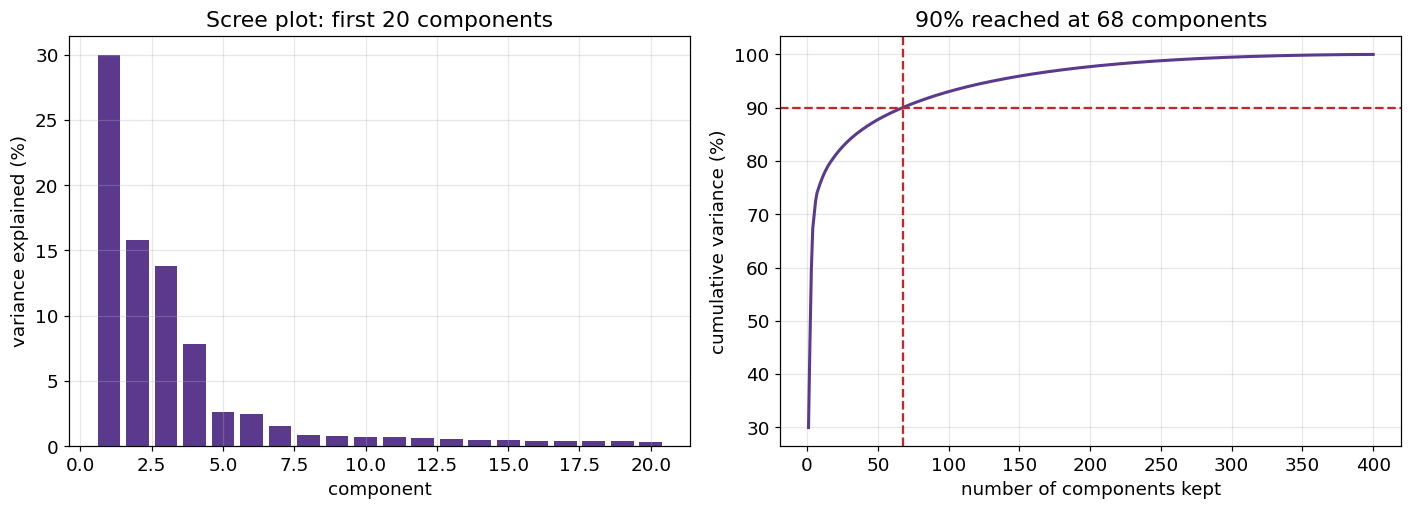

In [5]:
# --- TODO: how many components are needed to reach 90% of the total variance? ---
# np.cumsum gives running totals; np.searchsorted or a comparison plus .sum() will finish it.
cumulative = np.cumsum(var_frac)      # running total of var_frac
n_for_90   = np.where(cumulative>=0.9)[0][1]      # smallest number of components with cumulative variance >= 0.90
# if you have the data arrayed out in increasing order, at what point does their sum exceed 0.90
# we need about 68 components to explain 90% of the data

assert cumulative is not None and n_for_90 is not None, "Fill in both TODOs."
assert cumulative[-1] > 0.999, "cumulative should end at 1."
assert cumulative[n_for_90 - 1] >= 0.90 and cumulative[n_for_90 - 2] < 0.90, \
    "n_for_90 is not the smallest count reaching 90%."

print(f"components needed for 90% of the variance: {n_for_90} of {len(S)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(np.arange(1, 21), 100*var_frac[:20], color="#5b3a8e")
axes[0].set_xlabel("component"); axes[0].set_ylabel("variance explained (%)")
axes[0].set_title("Scree plot: first 20 components")

axes[1].plot(np.arange(1, len(S)+1), 100*cumulative, lw=2, color="#5b3a8e")
axes[1].axhline(90, ls="--", color="#c1272d")
axes[1].axvline(n_for_90, ls="--", color="#c1272d")
axes[1].set_xlabel("number of components kept"); axes[1].set_ylabel("cumulative variance (%)")
axes[1].set_title(f"90% reached at {n_for_90} components")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [6]:
cumulative = np.cumsum(var_frac)
# you want to index this element
indices_true = np.where(cumulative>=0.90)[0]
# literally tells you at what index this happens

first_true_index = np.argmax(cumulative>=0.9)

# find element that maximizes the given argument

print(indices_true[0], cumulative[indices_true[0]], np.argmax(cumulative>=0.9))

67 0.9006745423552212 67


---
## 5 — Projecting and plotting

Projecting sample $x$ onto component $v$ is the dot product $x \cdot v$, from section 3 of Meeting 4.
Doing it for every sample and the first two components at once is a single matrix product:

$$Z = \tilde{X}\, V_{[:2]}^{\top} \qquad Z \in \mathbb{R}^{n \times 2}$$

> `Vt[:2]` is a 2-by-400 array holding the first two components. Its transpose is 400-by-2, so
> `Xc @ Vt[:2].T` has shape 801-by-2 — two coordinates per tumour.

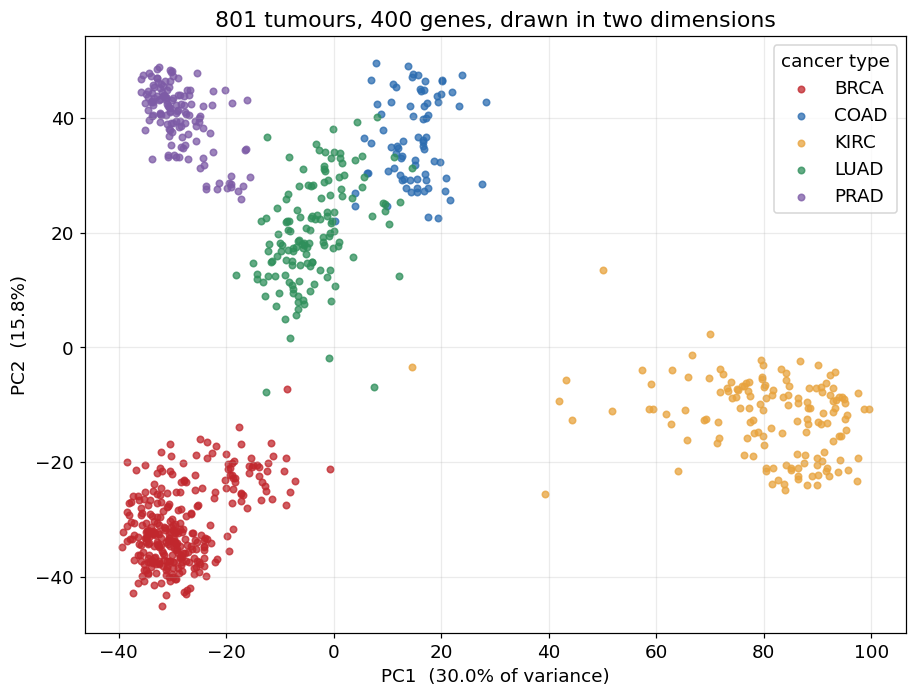

In [7]:
# --- TODO: project every sample onto the first two components ---
# Xc is 801 x 400
# Vt[:2] is 2 x 400
# To multiply them, we need ot first transpose Vt[:2]
Z = Xc @ Vt[:2].T       # shape (801, 2)
# project each row of matrix Xc on Vt for the first 2 rows of Vt

assert Z is not None, "Fill in Z."
assert Z.shape == (X.shape[0], 2), f"Z should have shape ({X.shape[0]}, 2), got {Z.shape}"
assert np.isclose(Z[:, 0].var(ddof=1), S[0]**2/(len(X)-1), rtol=1e-6), \
    "Variance along PC1 should equal its eigenvalue."

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for c, col in zip(sorted(set(y)), ["#c1272d", "#2b6cb0", "#e8a33d", "#2f8f5b", "#7d5ba6"]):
    m = y == c
    ax.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.75, color=col, label=c)
ax.set_xlabel(f"PC1  ({100*var_frac[0]:.1f}% of variance)")
ax.set_ylabel(f"PC2  ({100*var_frac[1]:.1f}%)")
ax.set_title("801 tumours, 400 genes, drawn in two dimensions")
ax.legend(title="cancer type"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

In [8]:
# check the shape of my 3 outputs from the SVD
# X = U @ S @ V.T where @ is matrix multiplication --> formula for SVD
U.shape, S.shape, Vt.shape

# Note: the rows of Vt are the columns of V
# We want to project our data onto the columns of V (ie, onto the rows of Vt)

((801, 400), (400,), (400, 400))

---
## 6 — What does PC1 actually measure?

A principal component is a vector of 400 numbers, one weight per gene. Genes with large weights
contribute most to that component, so inspecting them says what the component is responding to.

This is a property of PCA worth noting: because each component is a weighted sum of the original
features, it can be read. Most of the embeddings later in this course cannot be.

In [9]:
# --- TODO: find the 5 genes with the largest absolute weight in PC1 ---
# np.argsort sorts ascending and returns indices; np.abs gives magnitudes.
pc1 = Vt[0]
top5_idx = np.argsort(np.abs(pc1))[-1:-6:-1]       # indices of the 5 largest |weight| in pc1, largest first
# this sorts in ascending order, then says start from the last element and end on fifth to last element
# these are the five genes that contribute most strongly to pc1

assert top5_idx is not None, "Fill in top5_idx."
assert len(top5_idx) == 5, "Give exactly 5 indices."
assert np.abs(pc1[top5_idx[0]]) >= np.abs(pc1[top5_idx[-1]]), "Order them largest first."

print("Genes contributing most to PC1:\n")
for rank, j in enumerate(top5_idx, 1):
    print(f"  {rank}. {genes[j]:>12s}   weight {pc1[j]:+.4f}")

print(f"\nThese 5 of 400 genes carry "
      f"{100*np.sum(pc1[top5_idx]**2):.1f}% of PC1's total weight.")

Genes contributing most to PC1:

  1.    gene_3439   weight +0.1023
  2.    gene_3461   weight +0.0999
  3.   gene_19153   weight +0.0997
  4.    gene_6733   weight +0.0982
  5.   gene_19236   weight +0.0971

These 5 of 400 genes carry 4.9% of PC1's total weight.


---
## 7 — Submitting your work

**Due at 11:59 PM EST on Wednesday, September 23.**

1. `Runtime ▸ Restart session and run all`. Every cell must run without error, and every check must
   pass.
2. `File ▸ Download ▸ Download .ipynb`.
3. Rename the file to `YOUR-GITHUB-USERNAME_meeting05.ipynb` and move it into the `checkins/` folder
   of your clone.
4. Commit in GitHub Desktop, push, and open a pull request.
